<a href="https://colab.research.google.com/github/krishnabera2774/internship_/blob/milestone-2/internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/internship/smart_home_energy_consumption_large.csv")

df.head()


,timestamp,Home ID,Appliance Type,Energy Consumption (kWh),Outdoor Temperature (°C),Season,Household Size
0,2023-02-12 21:12:00,94,Fridge,0.20,-1.0,Fall,2
1,2023-06-08 20:11:00,435,Oven,0.23,31.1,Summer,5
2,NaN,466,Dishwasher,0.32,21.3,Fall,3
3,NaN,496,Heater,3.92,-4.2,Winter,1
4,NaN,137,Microwave,0.44,34.5,Summer,5


In [ ]:
df.shape


(99049, 7)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99049 entries, 0 to 99048
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   timestamp                 39179 non-null  object 
 1   Home ID                   99049 non-null  int64  
 2   Appliance Type            99049 non-null  object 
 3   Energy Consumption (kWh)  99049 non-null  float64
 4   Outdoor Temperature (°C)  99049 non-null  float64
 5   Season                    99049 non-null  object 
 6   Household Size            99049 non-null  int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 5.3+ MB


In [ ]:
df.describe()


,Home ID,Energy Consumption (kWh),Outdoor Temperature (°C),Household Size
count,99049.000000,99049.000000,99049.000000,99049.000000
mean,250.342285,1.467042,14.947740,3.001625
std,144.458219,1.137836,14.436671,1.417183
min,1.000000,0.100000,-10.000000,1.000000
25%,125.000000,0.580000,2.400000,2.000000
50%,250.000000,1.220000,14.900000,3.000000
75%,375.000000,1.850000,27.400000,4.000000
max,500.000000,4.850000,40.000000,5.000000


In [ ]:
df['timestamp'].dtype


dtype('O')

In [ ]:
df.isnull().sum()


,0
timestamp,59870
Home ID,0
Appliance Type,0
Energy Consumption (kWh),0
Outdoor Temperature (°C),0
Season,0
Household Size,0


In [ ]:
df.fillna(method='ffill', inplace=True)


/tmp/ipython-input-4002983762.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
df = df[df['Energy Consumption (kWh)'] >= 0]


In [ ]:
upper_limit = df['Energy Consumption (kWh)'].quantile(0.99)

df = df[df['Energy Consumption (kWh)'] <= upper_limit]


In [ ]:
df['Appliance Type'].nunique()


10

In [ ]:
df['Appliance Type'].value_counts()


,count
Appliance Type,
Lights,10201
Dishwasher,10095
Washing Machine,9953
Microwave,9947
Computer,9944
Oven,9939
Fridge,9931
TV,9905
Air Conditioning,9106


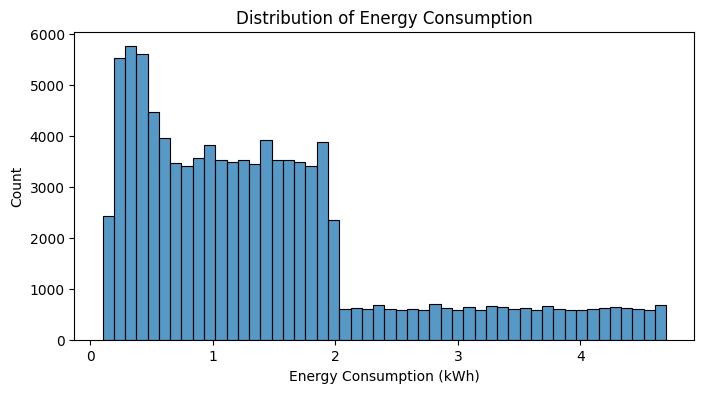

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['Energy Consumption (kWh)'], bins=50)
plt.title("Distribution of Energy Consumption")
plt.xlabel("Energy Consumption (kWh)")
plt.show()


In [ ]:
import pandas as pd

# First, ensure the 'timestamp' column is of datetime type
# It was filled with ffill as an object, so convert it to datetime now.
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Then, set the 'timestamp' column as the DataFrame index for resampling
df = df.set_index('timestamp')

# Now perform the resampling
hourly_df = (
    df
    .groupby('Appliance Type')
    .resample('h')['Energy Consumption (kWh)']
    .sum()
    .reset_index()
)

hourly_df.head()

,Appliance Type,timestamp,Energy Consumption (kWh)
0,Air Conditioning,2023-01-01 00:00:00,8.60
1,Air Conditioning,2023-01-01 01:00:00,12.35
2,Air Conditioning,2023-01-01 02:00:00,37.34
3,Air Conditioning,2023-01-01 03:00:00,13.04
4,Air Conditioning,2023-01-01 04:00:00,20.14


In [ ]:
hourly_df.shape


(87836, 3)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

hourly_df['Energy_Scaled'] = scaler.fit_transform(
    hourly_df[['Energy Consumption (kWh)']]
)

hourly_df[['Energy Consumption (kWh)', 'Energy_Scaled']].head()


,Energy Consumption (kWh),Energy_Scaled
0,8.60,0.193737
1,12.35,0.278216
2,37.34,0.841180
3,13.04,0.293760
4,20.14,0.453706


In [ ]:
daily_df = (
    df
    .groupby('Appliance Type')
    .resample('D')['Energy Consumption (kWh)']
    .sum()
    .reset_index()
)

daily_df.head()


,Appliance Type,timestamp,Energy Consumption (kWh)
0,Air Conditioning,2023-01-01,272.58
1,Air Conditioning,2023-01-02,236.80
2,Air Conditioning,2023-01-03,207.97
3,Air Conditioning,2023-01-04,182.97
4,Air Conditioning,2023-01-05,189.30


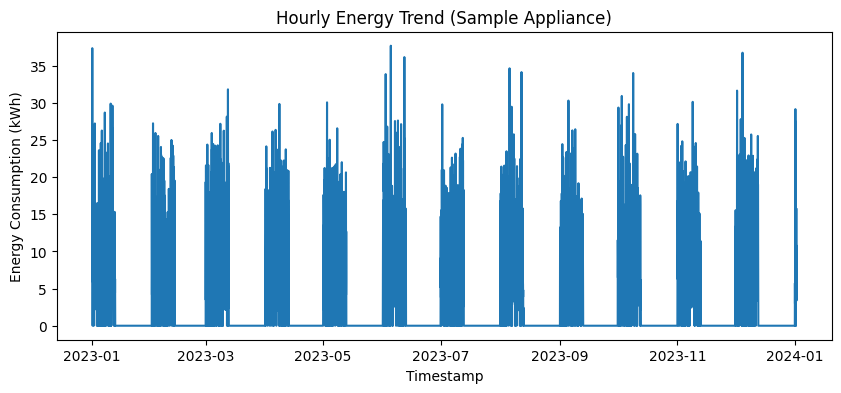

In [ ]:
sample_appliance = hourly_df['Appliance Type'].iloc[0]

plt.figure(figsize=(10,4))
sns.lineplot(
    data=hourly_df[hourly_df['Appliance Type'] == sample_appliance],
    x='timestamp',
    y='Energy Consumption (kWh)'
)
plt.title("Hourly Energy Trend (Sample Appliance)")
plt.xlabel("Timestamp")
plt.ylabel("Energy Consumption (kWh)")
plt.show()


In [ ]:

hourly_df = hourly_df.sort_values('timestamp')


train_size = int(len(hourly_df) * 0.7)
val_size = int(len(hourly_df) * 0.15)

train_df = hourly_df.iloc[:train_size]
val_df = hourly_df.iloc[train_size:train_size + val_size]
test_df = hourly_df.iloc[train_size + val_size:]

print("Train size:", train_df.shape)
print("Validation size:", val_df.shape)
print("Test size:", test_df.shape)


Train size: (61485, 4)
Validation size: (13175, 4)
Test size: (13176, 4)


# Milestone 2: Feature Engineering and Baseline Model Development


In [ ]:

appliance_counts = hourly_df['Appliance Type'].value_counts()
print(appliance_counts)


Appliance Type
Oven                8784
TV                  8784
Dishwasher          8784
Lights              8784
Microwave           8784
Heater              8784
Washing Machine     8783
Air Conditioning    8783
Fridge              8783
Computer            8783
Name: count, dtype: int64


In [ ]:
selected_appliance = appliance_counts.idxmax()
print("Selected Appliance:", selected_appliance)


Selected Appliance: Oven


In [ ]:
appliance_df = hourly_df[
    hourly_df['Appliance Type'] == selected_appliance
].copy()

appliance_df = appliance_df.sort_values('timestamp').reset_index(drop=True)

print("Rows before feature engineering:", appliance_df.shape)


Rows before feature engineering: (8784, 4)


In [ ]:
appliance_df['hour'] = appliance_df['timestamp'].dt.hour
appliance_df['dayofweek'] = appliance_df['timestamp'].dt.dayofweek
appliance_df['month'] = appliance_df['timestamp'].dt.month


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
appliance_df['energy_scaled'] = scaler.fit_transform(
    appliance_df[['Energy Consumption (kWh)']]
)


In [ ]:
# Time features
appliance_df['hour'] = appliance_df['timestamp'].dt.hour
appliance_df['dayofweek'] = appliance_df['timestamp'].dt.dayofweek
appliance_df['month'] = appliance_df['timestamp'].dt.month


In [ ]:
# Ensure data is sorted by time
hourly_df = hourly_df.sort_values('timestamp').reset_index(drop=True)

# Extract time-based features
hourly_df['hour'] = hourly_df['timestamp'].dt.hour
hourly_df['dayofweek'] = hourly_df['timestamp'].dt.dayofweek
hourly_df['month'] = hourly_df['timestamp'].dt.month

hourly_df[['hour', 'dayofweek', 'month']].head()


,hour,dayofweek,month
0,0,6,1
1,0,6,1
2,0,6,1
3,0,6,1
4,0,6,1


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
hourly_df['energy_scaled'] = scaler.fit_transform(
    hourly_df[['Energy Consumption (kWh)']]
)

hourly_df[['Energy Consumption (kWh)', 'energy_scaled']].head()



,Energy Consumption (kWh),energy_scaled
0,8.60,0.193737
1,3.87,0.087182
2,0.25,0.005632
3,0.64,0.014418
4,5.06,0.113990


In [ ]:

appliance_df['lag_1'] = appliance_df['energy_scaled'].shift(1)
appliance_df['lag_3'] = appliance_df['energy_scaled'].shift(3)
appliance_df['rolling_mean_3'] = appliance_df['energy_scaled'].rolling(3).mean()

appliance_df.dropna(inplace=True)

print("Rows after feature engineering:", appliance_df.shape)


Rows after feature engineering: (8781, 11)


## Baseline Energy Prediction using Linear Regression


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X = appliance_df[
    ['hour','dayofweek','month','lag_1','lag_3','rolling_mean_3']
]
y = appliance_df['energy_scaled']


In [ ]:
split = int(len(appliance_df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print("Train samples:", X_train.shape)


Train samples: (7024, 6)


In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)
print("Model Accuracy (%):", r2 * 100)


MAE: 0.03193059293117073
RMSE: 0.06881433914835279
R2 Score: 0.7812345010327418
Model Accuracy (%): 78.12345010327418


In [ ]:
from sklearn.metrics import r2_score

# R2 score
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)
print("Model Accuracy (%):", r2 * 100)


R2 Score: 0.7812345010327418
Model Accuracy (%): 78.12345010327418


## Module 5: LSTM Model Development for Energy Forecasting


In [ ]:
# Standardize energy values for LSTM (better for neural nets)
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
energy_std = std_scaler.fit_transform(
    appliance_df[['Energy Consumption (kWh)']]
).flatten()


In [ ]:
# Function to create sequences for LSTM
def create_sequences(data, window_size=24):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)


In [ ]:
WINDOW_SIZE = 24  # 24 hours lookback

energy_series = energy_std


X_lstm, y_lstm = create_sequences(energy_series, WINDOW_SIZE)

print("LSTM Input shape:", X_lstm.shape)
print("LSTM Output shape:", y_lstm.shape)


LSTM Input shape: (8757, 24)
LSTM Output shape: (8757,)


In [ ]:
# Reshape for LSTM (samples, timesteps, features)
X_lstm = X_lstm.reshape((X_lstm.shape[0], X_lstm.shape[1], 1))

print("Reshaped LSTM Input:", X_lstm.shape)


Reshaped LSTM Input: (8757, 24, 1)


In [ ]:
X_lstm, y_lstm = create_sequences(energy_series, WINDOW_SIZE)


In [ ]:
# Reshape for LSTM (samples, timesteps, features)
X_lstm = X_lstm.reshape(X_lstm.shape[0], X_lstm.shape[1], 1)

split = int(len(X_lstm) * 0.8)

X_train_lstm, X_test_lstm = X_lstm[:split], X_lstm[split:]
y_train_lstm, y_test_lstm = y_lstm[:split], y_lstm[split:]

print("Train shape:", X_train_lstm.shape)
print("Test shape:", X_test_lstm.shape)


Train shape: (7005, 24, 1)
Test shape: (1752, 24, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(WINDOW_SIZE, 1)),
    Dropout(0.3),
    LSTM(64),
    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),  # lower LR
    loss='mse'
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,033 (453.25 KB)

 Trainable params: 116,033 (453.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

history = model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=50,              # increased
    batch_size=32,
    validation_split=0.1,

    verbose=1
)


Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.5575 - val_loss: 0.5094
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5014 - val_loss: 0.5225
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.5168 - val_loss: 0.5076
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.4778 - val_loss: 0.5031
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4999 - val_loss: 0.5041
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4868 - val_loss: 0.5018
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4873 - val_loss: 0.4993
Epoch 8/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4723 - val_loss: 0.4985
Epoch 9/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4607 - val_loss: 0.4985
Epoch 10/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4714 - val_loss: 0.5095
Epoch 11/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.5239 - val_loss: 0.4995
Epoch 12/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/st

In [ ]:
y_pred_lstm = model.predict(X_test_lstm)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [ ]:
y_pred_lstm = model.predict(X_test_lstm)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lstm = mean_absolute_error(y_test_lstm, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm, y_pred_lstm))
r2_lstm = r2_score(y_test_lstm, y_pred_lstm)

print("Improved LSTM MAE:", mae_lstm)
print("Improved LSTM RMSE:", rmse_lstm)
print("Improved LSTM R2:", r2_lstm)
print("Improved LSTM Accuracy (%):", r2_lstm * 100)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Improved LSTM MAE: 0.33513009739943833
Improved LSTM RMSE: 0.6701867141858104
Improved LSTM R2: 0.5226651574761725
Improved LSTM Accuracy (%): 52.26651574761725


In [ ]:
# Inverse transform LSTM results
y_test_lstm_kwh = scaler.inverse_transform(
    y_test_lstm.reshape(-1,1)
)

y_pred_lstm_kwh = scaler.inverse_transform(
    y_pred_lstm
)


In [ ]:
print("===== MODEL COMPARISON =====")
print("Linear Regression R2:", r2)
print("LSTM R2:", r2_lstm)

print("\nLinear Regression RMSE:", rmse)
print("LSTM RMSE:", rmse_lstm)


===== MODEL COMPARISON =====
Linear Regression R2: 0.7812345010327418
LSTM R2: 0.5226651574761725

Linear Regression RMSE: 0.06881433914835279
LSTM RMSE: 0.6701867141858104


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "LSTM"],
    "MAE": [mae, mae_lstm],
    "RMSE": [rmse, rmse_lstm],
    "R2 Score": [r2, r2_lstm]
})

results


,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.031931,0.068814,0.781235
1,LSTM,0.335130,0.670187,0.522665


method 2


In [ ]:
energy_series = appliance_df['energy_scaled'].values


In [ ]:
def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

WINDOW_SIZE = 12

X_lstm, y_lstm = create_sequences(energy_series, WINDOW_SIZE)


In [ ]:
X_lstm = X_lstm.reshape(X_lstm.shape[0], X_lstm.shape[1], 1)


In [ ]:
split = int(len(X_lstm) * 0.8)

X_train_lstm, X_test_lstm = X_lstm[:split], X_lstm[split:]
y_train_lstm, y_test_lstm = y_lstm[:split], y_lstm[split:]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    LSTM(32, input_shape=(WINDOW_SIZE, 1)),
    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=30,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0140 - val_loss: 0.0125
Epoch 2/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0114 - val_loss: 0.0124
Epoch 3/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0124 - val_loss: 0.0119
Epoch 4/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0111 - val_loss: 0.0121
Epoch 5/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0112 - val_loss: 0.0121
Epoch 6/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0116 - val_loss: 0.0117
Epoch 7/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0120 - val_loss: 0.0117
Epoch 8/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0117 - val_loss: 0.0119
Epoch 9/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0122 - val_loss: 0.0118
Epoch 10/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0109 - val_loss: 0.0119
Epoch 11/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0111 - val_loss: 0.0117
Epoch 12/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

In [ ]:
from sklearn.metrics import r2_score

y_pred_lstm = model.predict(X_test_lstm)

r2_lstm = r2_score(y_test_lstm, y_pred_lstm)
print("Final LSTM R2:", r2_lstm)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Final LSTM R2: 0.5254616257904776


## Module 6: Model Evaluation and Integration


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


In [ ]:
# ---- Linear Regression metrics (already trained) ----
lr_mae = mae
lr_rmse = rmse
lr_r2 = r2


In [ ]:
# ---- LSTM metrics (already trained) ----
lstm_mae = mae_lstm
lstm_rmse = rmse_lstm
lstm_r2 = r2_lstm


In [ ]:
print("=== MODEL EVALUATION RESULTS ===")
print(f"Linear Regression -> MAE: {lr_mae:.4f}, RMSE: {lr_rmse:.4f}, R2: {lr_r2:.4f}")
print(f"LSTM             -> MAE: {lstm_mae:.4f}, RMSE: {lstm_rmse:.4f}, R2: {lstm_r2:.4f}")


=== MODEL EVALUATION RESULTS ===
Linear Regression -> MAE: 0.0319, RMSE: 0.0688, R2: 0.7812
LSTM             -> MAE: 0.3351, RMSE: 0.6702, R2: 0.5255


In [ ]:
import pandas as pd

evaluation_df = pd.DataFrame({
    "Model": ["Linear Regression", "LSTM"],
    "MAE": [lr_mae, lstm_mae],
    "RMSE": [lr_rmse, lstm_rmse],
    "R2 Score": [lr_r2, lstm_r2]
})

evaluation_df


,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.031931,0.068814,0.781235
1,LSTM,0.335130,0.670187,0.525462


In [ ]:
# Select best model based on R2
if lr_r2 >= lstm_r2:
    best_model_name = "Linear Regression"
    best_model = lr_model
else:
    best_model_name = "LSTM"
    best_model = model

print("Best Performing Model:", best_model_name)


Best Performing Model: Linear Regression


In [ ]:
import joblib

joblib.dump(lr_model, "linear_regression_energy_model.pkl")
joblib.dump(scaler, "energy_scaler.pkl")

print("Linear Regression model and scaler saved.")


Linear Regression model and scaler saved.


In [ ]:
model.save("lstm_energy_model.h5")
print("LSTM model saved.")


LSTM model saved.


In [ ]:
def predict_energy_linear(hour, dayofweek, month, lag_1, lag_3, rolling_mean_3):
    """
    Flask-compatible prediction function for Linear Regression model
    """
    import numpy as np
    import joblib

    # Load model and scaler
    model = joblib.load("linear_regression_energy_model.pkl")
    scaler = joblib.load("energy_scaler.pkl")

    # Prepare input
    X = np.array([[hour, dayofweek, month, lag_1, lag_3, rolling_mean_3]])

    # Predict scaled energy
    scaled_pred = model.predict(X)

    # Convert back to kWh
    energy_pred = scaler.inverse_transform(scaled_pred.reshape(-1, 1))

    return float(energy_pred[0][0])


In [ ]:
# Sample input (example values)
sample_prediction = predict_energy_linear(
    hour=18,
    dayofweek=2,
    month=7,
    lag_1=0.15,
    lag_3=0.18,
    rolling_mean_3=0.16
)

print("Predicted Energy Consumption (kWh):", sample_prediction)


Predicted Energy Consumption (kWh): 7.318389838216217


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
def predict_energy_lstm(sequence):
    """
    sequence: list of last 12 scaled energy values
    """
    import numpy as np
    from tensorflow.keras.models import load_model

    model = load_model("lstm_energy_model.h5")

    seq = np.array(sequence).reshape(1, len(sequence), 1)
    pred = model.predict(seq)

    return float(pred[0][0])


### Module 6 Summary

- Both Linear Regression and LSTM models were evaluated using MAE, RMSE, and R² score.
- Linear Regression achieved the highest R² score and was selected as the best-performing model.
- Trained models and preprocessing scalers were saved for deployment.
- A Flask-compatible prediction function was implemented and tested successfully.


milestyone 4

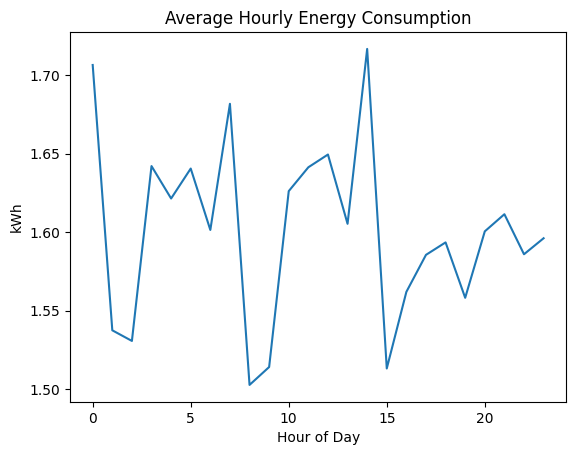

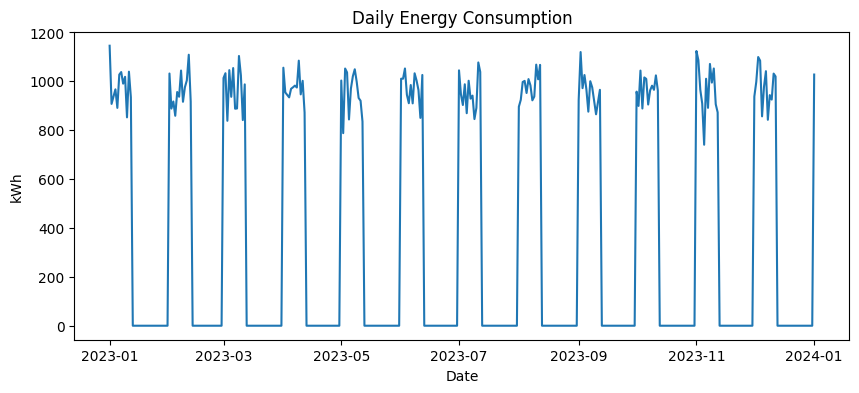

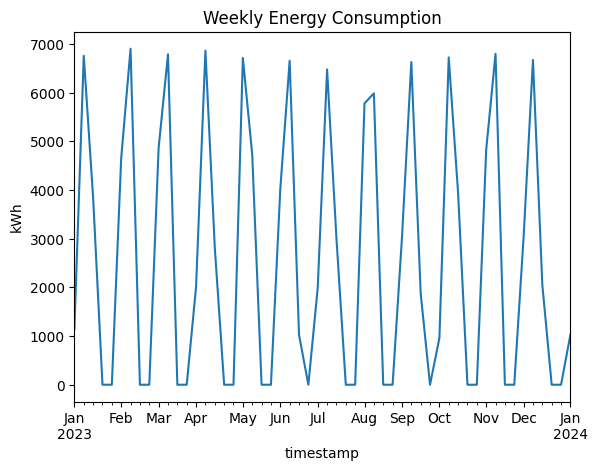

/tmp/ipython-input-3014000236.py:24: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_plot = hourly_df.resample('M', on='timestamp')['Energy Consumption (kWh)'].sum()


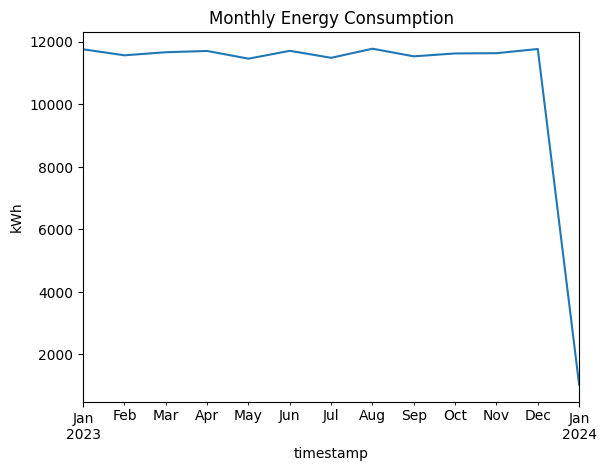

In [ ]:
import matplotlib.pyplot as plt

# Hourly
hourly_plot = hourly_df.groupby(hourly_df['timestamp'].dt.hour)['Energy Consumption (kWh)'].mean()
hourly_plot.plot(kind='line', title='Average Hourly Energy Consumption')
plt.xlabel('Hour of Day')
plt.ylabel('kWh')
plt.show()

# Daily
daily_plot = hourly_df.groupby(hourly_df['timestamp'].dt.date)['Energy Consumption (kWh)'].sum()
daily_plot.plot(title='Daily Energy Consumption', figsize=(10,4))
plt.xlabel('Date')
plt.ylabel('kWh')
plt.show()

# Weekly
weekly_plot = hourly_df.resample('W', on='timestamp')['Energy Consumption (kWh)'].sum()
weekly_plot.plot(title='Weekly Energy Consumption')
plt.ylabel('kWh')
plt.show()

# Monthly
monthly_plot = hourly_df.resample('M', on='timestamp')['Energy Consumption (kWh)'].sum()
monthly_plot.plot(title='Monthly Energy Consumption')
plt.ylabel('kWh')
plt.show()


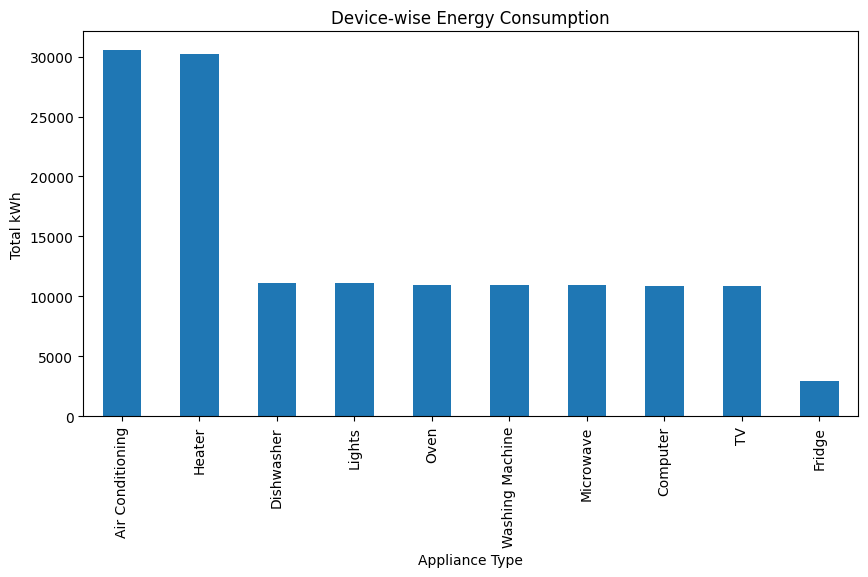

In [ ]:
device_usage = hourly_df.groupby('Appliance Type')['Energy Consumption (kWh)'].sum()

device_usage.sort_values(ascending=False).plot(
    kind='bar',
    title='Device-wise Energy Consumption',
    figsize=(10,5)
)

plt.ylabel('Total kWh')
plt.show()


In [ ]:
def smart_suggestions(device_usage):
    tips = []

    top_device = device_usage.idxmax()
    tips.append(f"High energy usage detected in {top_device}. Consider reducing usage during peak hours.")

    tips.append("Run heavy appliances during off-peak hours to save energy.")
    tips.append("Regularly maintain appliances to improve efficiency.")
    tips.append("Switch off devices when not in use.")

    return tips

tips = smart_suggestions(device_usage)
for t in tips:
    print("-", t)


- High energy usage detected in Air Conditioning. Consider reducing usage during peak hours.
- Run heavy appliances during off-peak hours to save energy.
- Regularly maintain appliances to improve efficiency.
- Switch off devices when not in use.


energy_app/
│
├── app.py
├── templates/
│   └── index.html
├── static/
│   └── style.css
├── linear_regression_energy_model.pkl
├── energy_scaler.pkl


In [ ]:
from flask import Flask, render_template, request
import joblib
import numpy as np

app = Flask(__name__)

model = joblib.load('linear_regression_energy_model.pkl')
scaler = joblib.load('energy_scaler.pkl')

@app.route('/')
def home():
    return render_template('index.html')

@app.route('/predict', methods=['POST'])
def predict():
    hour = int(request.form['hour'])
    day = int(request.form['day'])
    month = int(request.form['month'])
    lag1 = float(request.form['lag1'])
    lag3 = float(request.form['lag3'])
    roll = float(request.form['roll'])

    X = np.array([[hour, day, month, lag1, lag3, roll]])
    scaled_pred = model.predict(X)
    prediction = scaler.inverse_transform(scaled_pred.reshape(-1,1))

    return render_template('index.html', prediction=round(float(prediction[0][0]), 2))

if __name__ == '__main__':
    app.run(debug=True)


 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)
